In [21]:
import pandas as pd  
from sklearn.datasets import fetch_california_housing

import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 


In [22]:
df= fetch_california_housing()
dataset=pd.DataFrame(df.data,columns=df.feature_names)

In [23]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [24]:
#independent features and dependent features 
x=dataset ## all features 
y=df.target # all targets(outputs)

              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   

            Latitude  Longitude  
MedInc     -0.079809  -0.015176  
HouseAge    0.011173  -0.108197  
AveRooms    0.106389  -0.027540  
AveBedrms   0.069721   0.013344  
Population -0.108785   0.099773  
AveOccup    0.002366   0.002476  
Latitude    1.000000  -0.924664  
Longitude  -0.924664   1.000000  


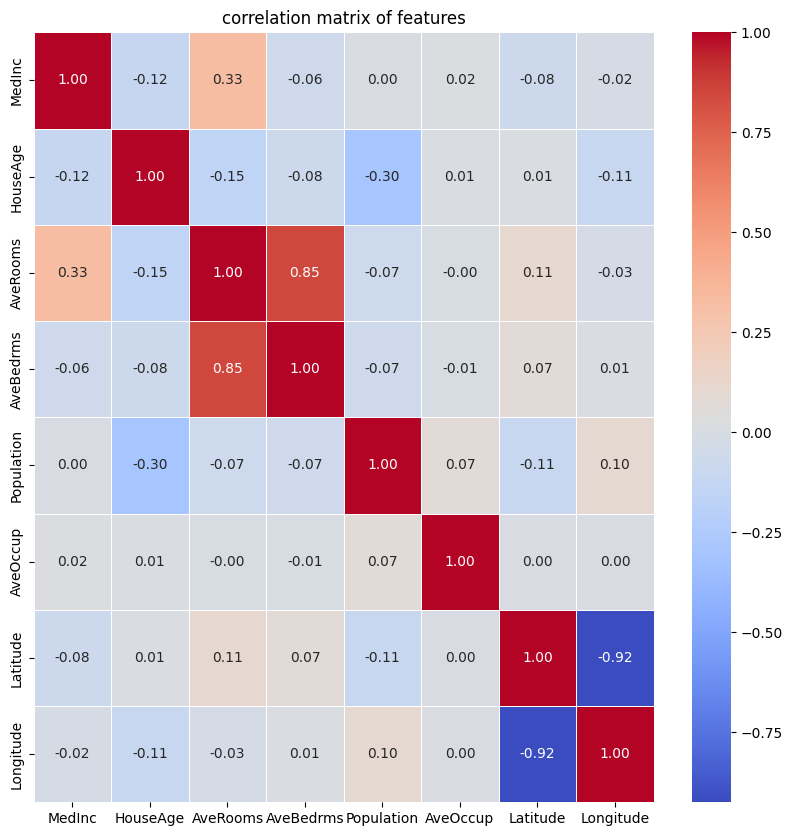

In [25]:
corr_matrix=dataset.corr(numeric_only=True) # this will work as it drops columns have non numeric data
print(corr_matrix)
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('correlation matrix of features')
plt.show()

In [26]:
# train test my data 

from sklearn.model_selection import  train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [27]:
# standerdizing the dataset
from sklearn.preprocessing import  StandardScaler
scaler=StandardScaler()# initialisiation


In [28]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [30]:
regression=LinearRegression()
regression.fit(x_train,y_train)
mse=cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',cv=5)
np.mean(mse)

np.float64(-0.5268253746355748)

In [31]:
reg_pred=regression.predict(x_test)


In [32]:
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133], shape=(6192,))

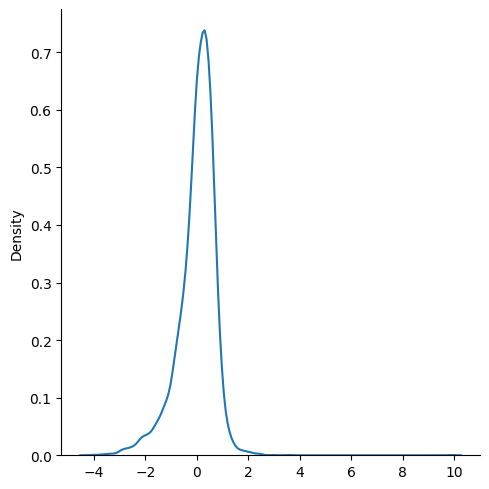

In [33]:
import seaborn as sns 
sns.displot(reg_pred-y_test,kind='kde')

In [34]:
from sklearn.metrics import r2_score


In [35]:
score=r2_score(reg_pred,y_test)
score

0.3451339380943991

{'alpha': 5}
-0.5268179966861513


In [38]:
ridge_pred=ridgecv.predict(x_test)
score=r2_score(y_test,ridge_pred)
score 

0.595859738951996